# Exercise 4b: Image Morphology

In [102]:
from skimage import color, io, measure, img_as_ubyte
from skimage.measure import profile_line
from skimage.transform import rescale, resize
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt
import numpy as np
import pydicom as dicom

In [103]:
from skimage.morphology import erosion, dilation, opening, closing
from skimage.morphology import disk 

In [104]:
# From https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html
def plot_comparison(original, filtered, filter_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis('off')
    io.show()

## Exercise 1

In [105]:
# Directory containing images
in_dir = "data/"

# Lego 5 image
im_name = "lego_5.png"

# Read the image
im_org = io.imread(in_dir + im_name)

In [106]:
im_org_grayscale = color.rgb2gray(im_org)

In [107]:
thres = threshold_otsu(im_org_grayscale)
bin_img = im_org_grayscale < thres # The ROI is usually with 

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


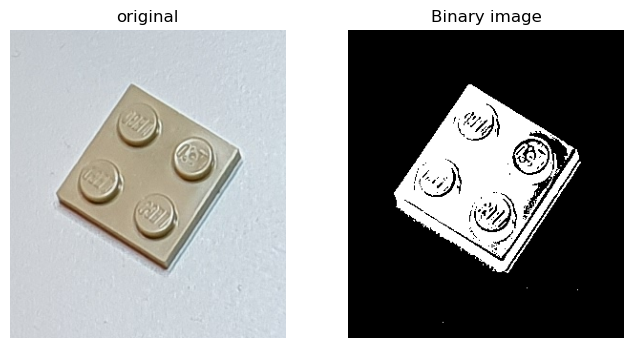

In [108]:
plot_comparison(im_org, bin_img, 'Binary image')

## Exercise 2

In [109]:
footprint = disk(2)
# Check the size and shape of the structuring element
print(footprint)

[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


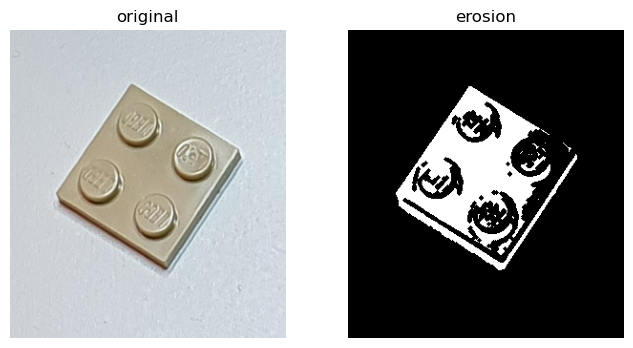

In [110]:
eroded = erosion(bin_img, footprint)
plot_comparison(im_org, eroded, 'erosion')

## Exercise 3

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


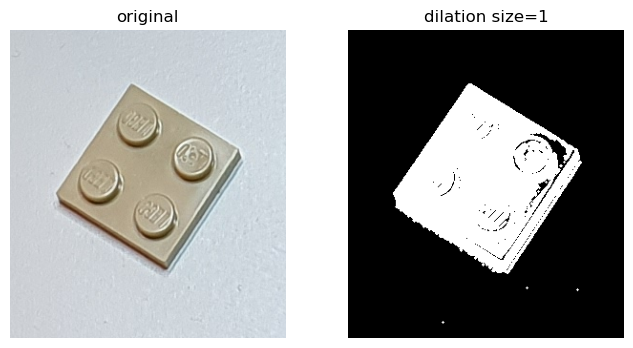

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


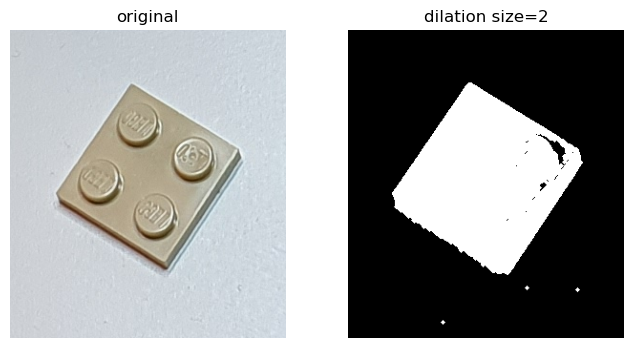

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


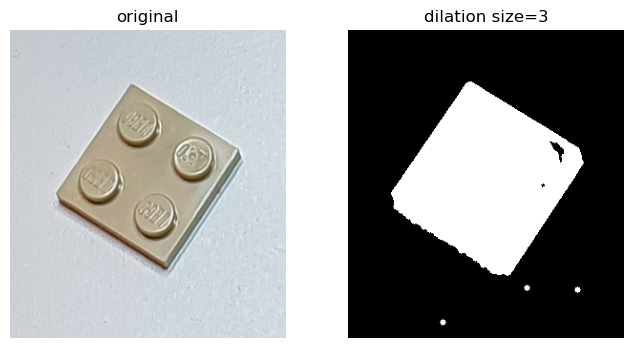

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


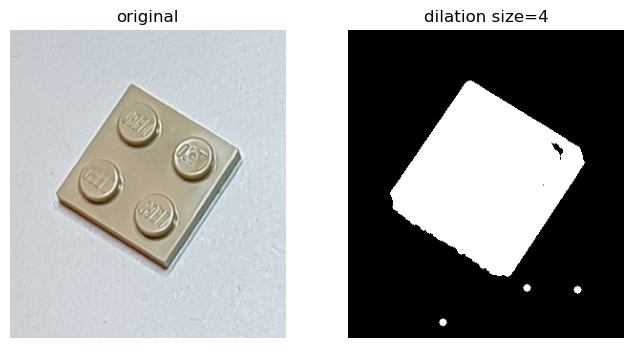

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


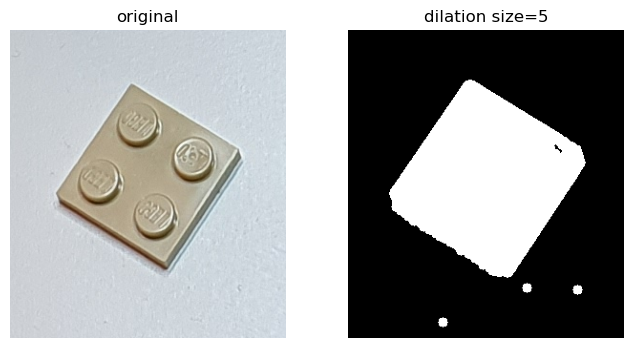

In [111]:
for i in range(1,6):
    footprint = disk(i)

    dilated = dilation(bin_img, footprint)
    plot_comparison(im_org, dilated, f'dilation size={i}')

## Exercise 4

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


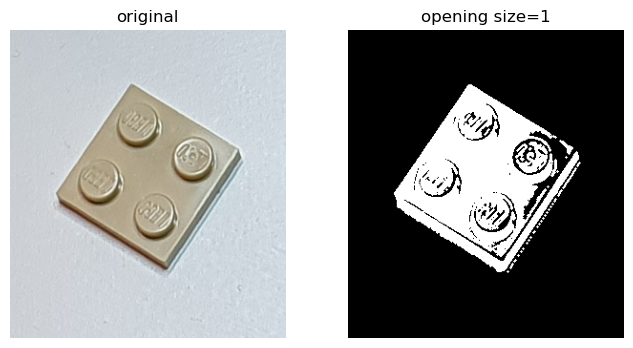

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


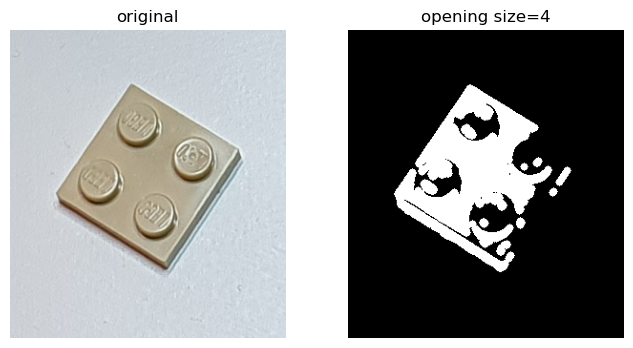

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


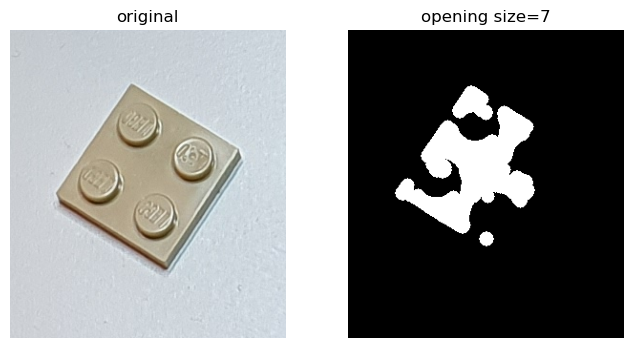

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


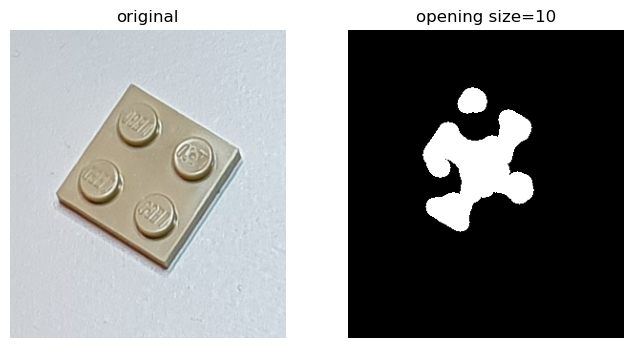

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


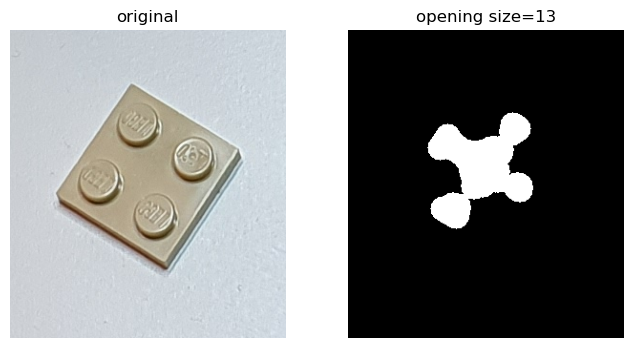

In [112]:
# Opening: erosion + dilation

for i in range(1,16,3):
    footprint = disk(i)

    opened = opening(bin_img, footprint)
    plot_comparison(im_org, opened, f'opening size={i}')

## Exercise 5

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


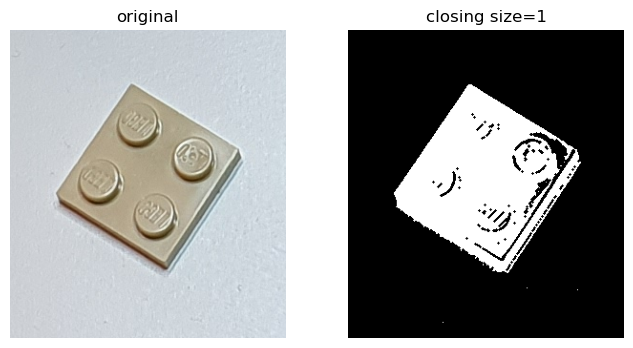

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


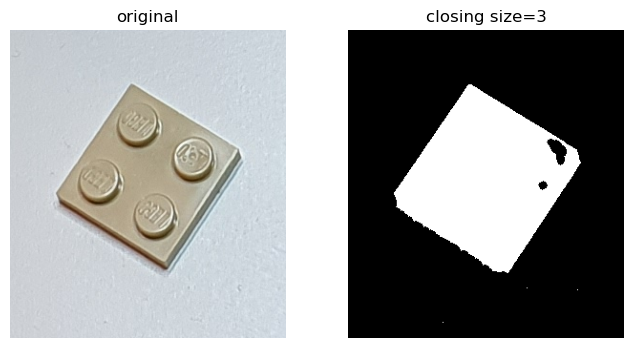

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


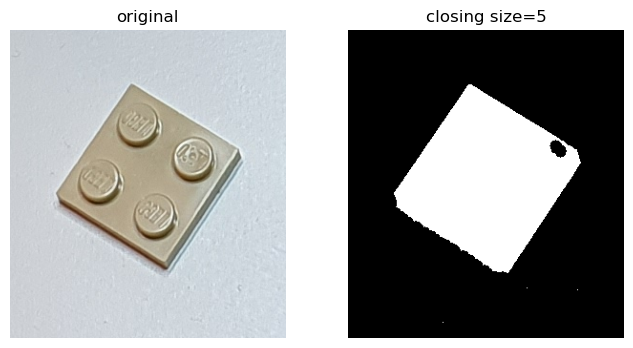

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


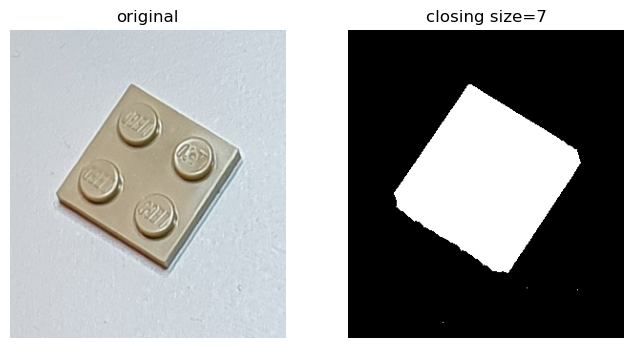

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


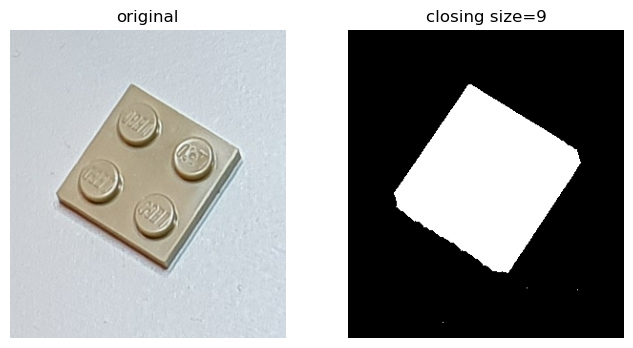

In [113]:
# Closing: dilation + erosion

for i in range(1,10,2):
    footprint = disk(i)

    closed = closing(bin_img, footprint)
    plot_comparison(im_org, closed, f'closing size={i}')

## Exercise 6

In [114]:
def compute_outline(bin_img):
    """
    Computes the outline of a binary image
    """
    footprint = disk(1)
    dilated = dilation(bin_img, footprint)
    outline = np.logical_xor(dilated, bin_img)
    return outline

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


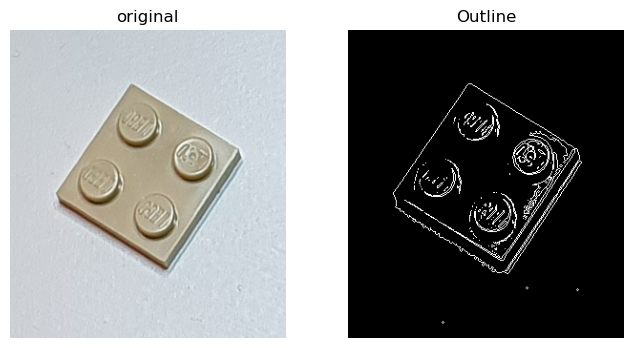

In [115]:
outline_img = compute_outline(bin_img)
plot_comparison(im_org, outline_img, 'Outline')

## Exercise 7

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


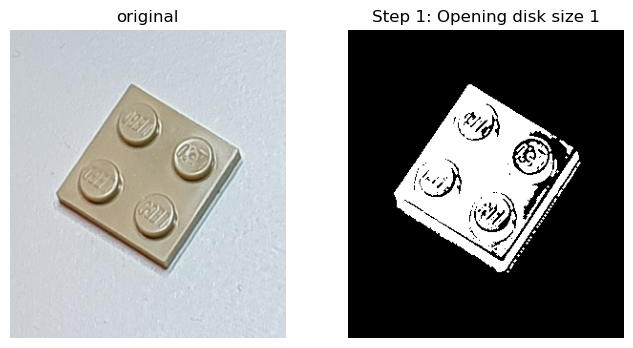

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


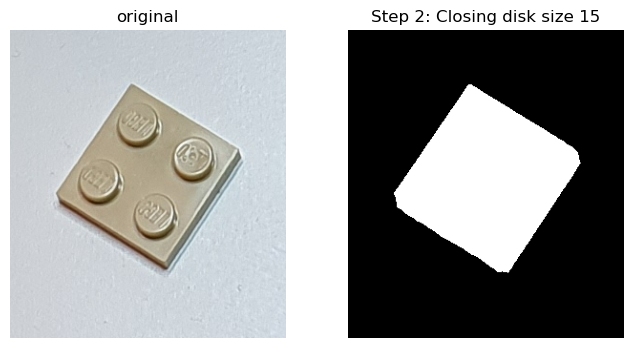

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


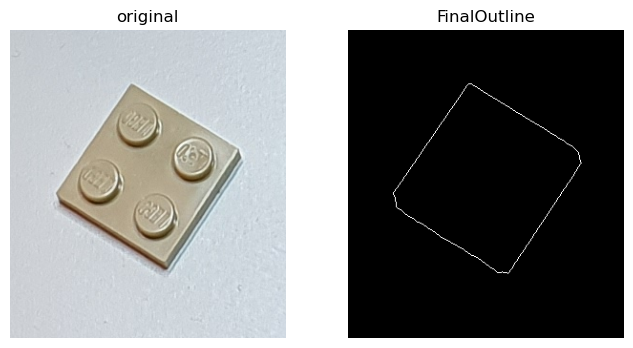

In [116]:
# opening with a disk of size 1
opened = opening(bin_img, disk(1))
plot_comparison(im_org, opened, 'Step 1: Opening disk size 1')

# closing with a disk of size 15
closed = closing(opened, disk(15))
plot_comparison(im_org, closed, 'Step 2: Closing disk size 15')

# outline
outline_img = compute_outline(closed)
plot_comparison(im_org, outline_img, 'FinalOutline')

Explain why!!

## Morphology on multiple objects

## Exercise 8

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


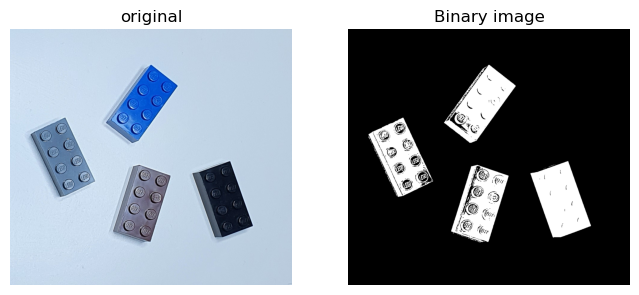

In [117]:
# Lego 7 image
im_name = "lego_7.png"

# Read the image
im_org = io.imread(in_dir + im_name)

# Grayscale
im_org_grayscale = color.rgb2gray(im_org)

# Otsu threshold
thres = threshold_otsu(im_org_grayscale)
bin_img = im_org_grayscale < thres

# Comparison
plot_comparison(im_org, bin_img, 'Binary image')

## Exercise 9

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


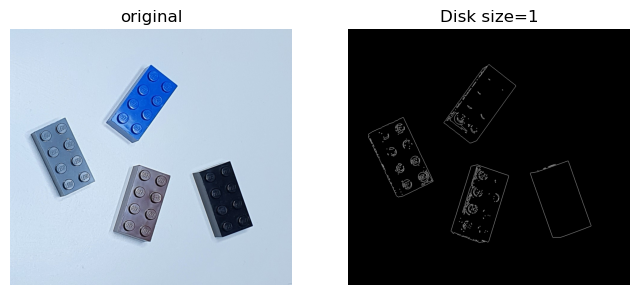

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


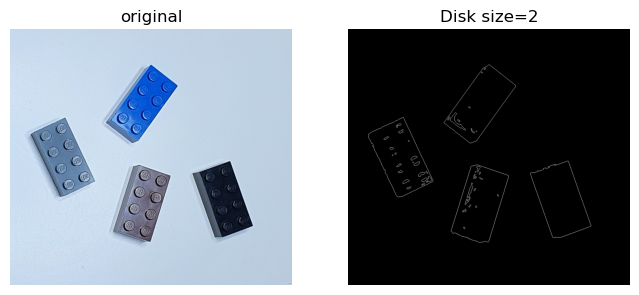

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


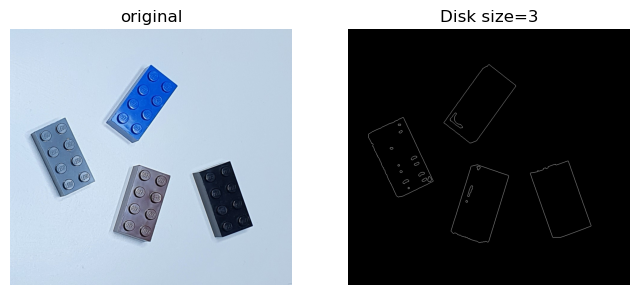

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


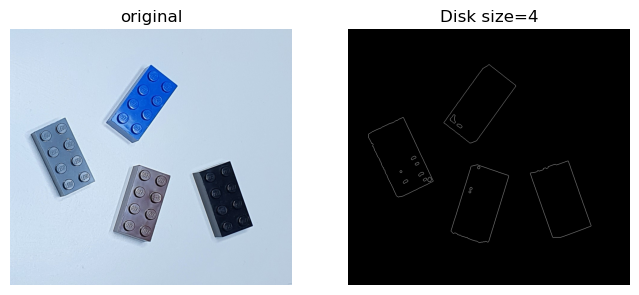

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


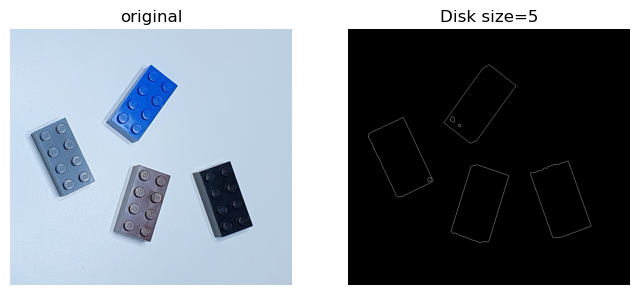

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


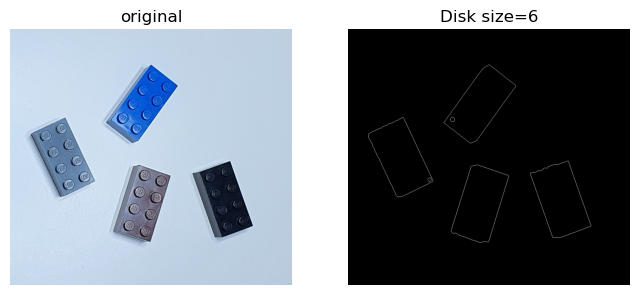

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


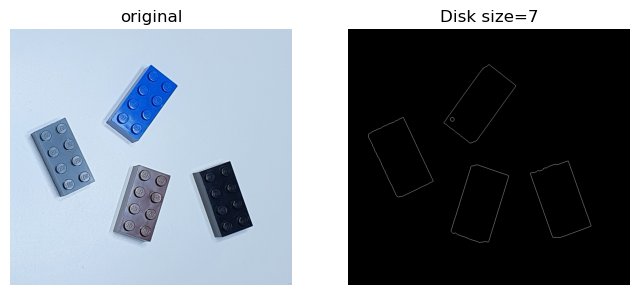

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


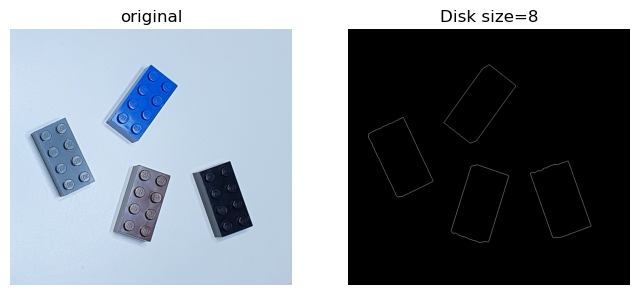

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


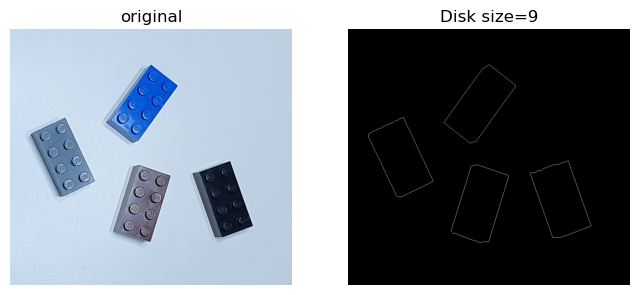

In [118]:
for i in range(1,10):
    closed = closing(bin_img, disk(i))
    outline_img = compute_outline(closed)
    plot_comparison(im_org, outline_img, f'Disk size={i}')

Closing with disk size 8 gives the desired result.

## Exercise 10

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


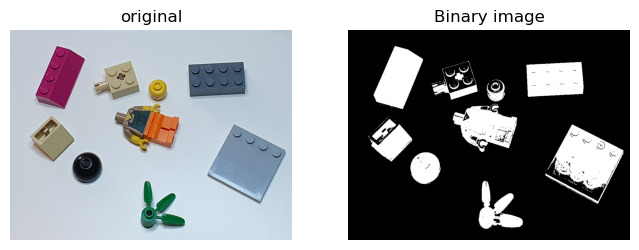

In [119]:
# Lego 3 image
im_name = "lego_3.png"

# Read the image
im_org = io.imread(in_dir + im_name)

# Grayscale
im_org_grayscale = color.rgb2gray(im_org)

# Otsu threshold
thres = threshold_otsu(im_org_grayscale)
bin_img = im_org_grayscale < thres

# Comparison
plot_comparison(im_org, bin_img, 'Binary image')

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


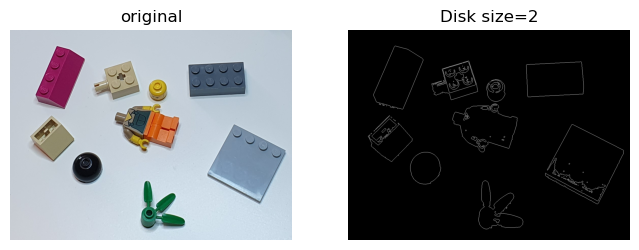

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


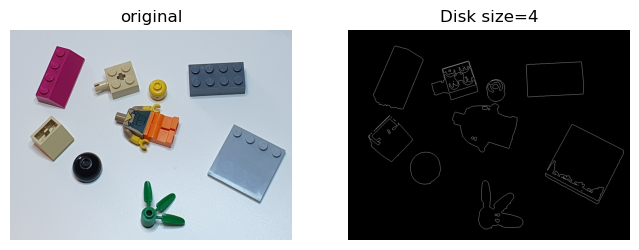

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


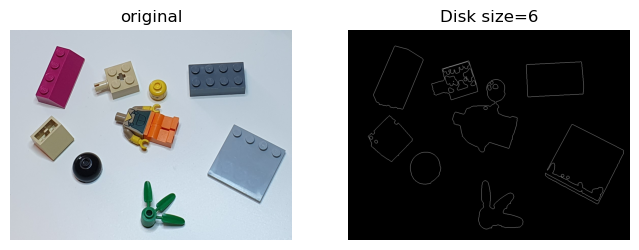

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


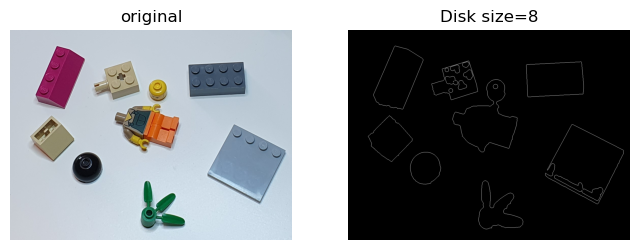

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


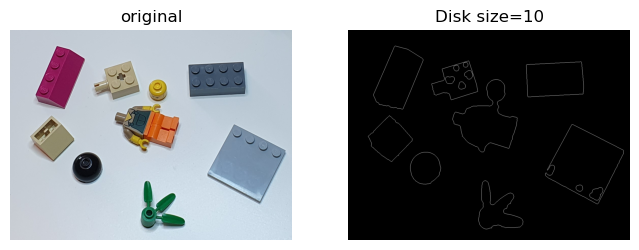

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


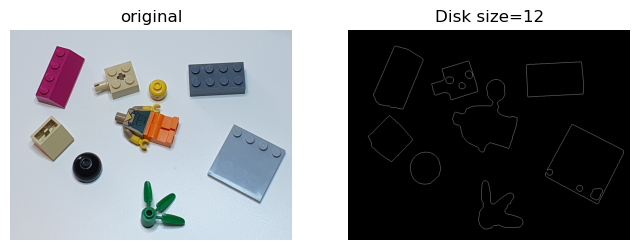

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


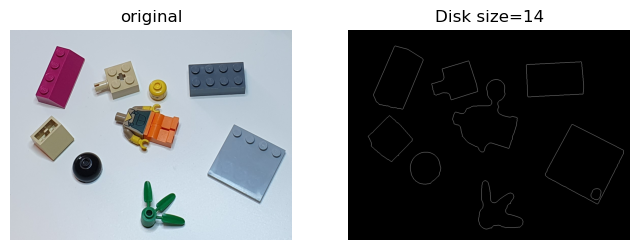

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


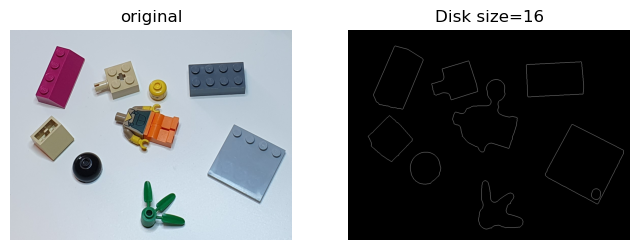

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


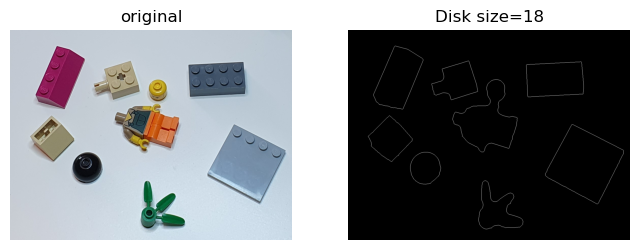

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


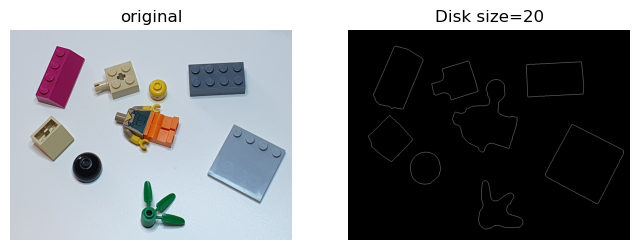

In [120]:
for i in range(2,21,2):
    closed = closing(bin_img, disk(i))
    outline_img = compute_outline(closed)
    plot_comparison(im_org, outline_img, f'Disk size={i}')

A much higher disk size is needed in this case to obtain the desired result. -> WHY?

## Morphology on multiple connected objects

## Exercise 11

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


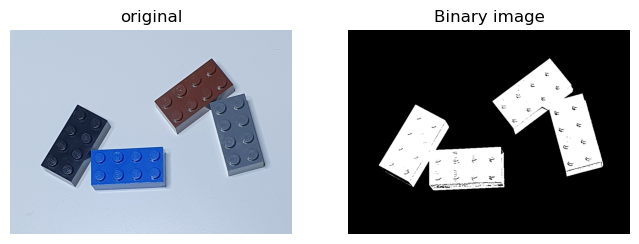

In [121]:
# Lego 9 image
im_name = "lego_9.png"

# Read the image
im_org = io.imread(in_dir + im_name)

# Grayscale
im_org_grayscale = color.rgb2gray(im_org)

# Otsu threshold
thres = threshold_otsu(im_org_grayscale)
bin_img = im_org_grayscale < thres

# Comparison
plot_comparison(im_org, bin_img, 'Binary image')

## Exercise 12

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


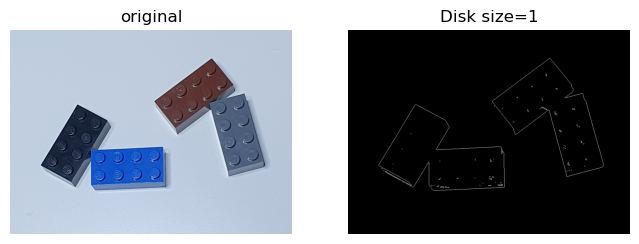

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


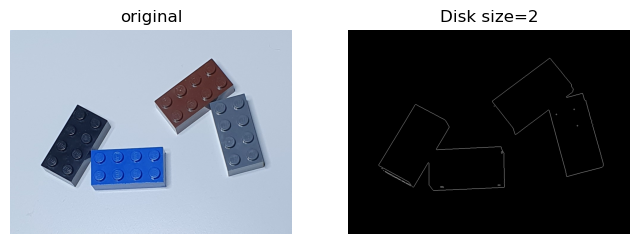

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


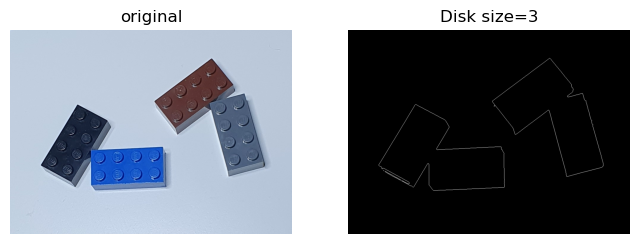

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


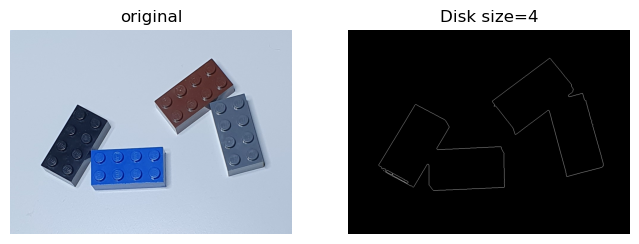

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


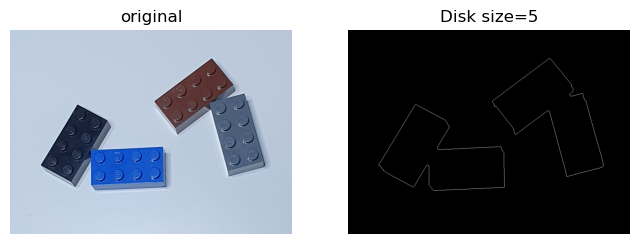

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


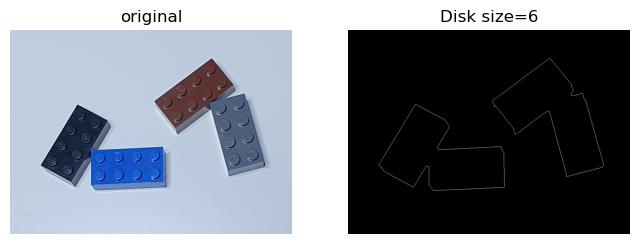

In [122]:
for i in range(1,7):
    closed = closing(bin_img, disk(i))
    outline_img = compute_outline(closed)
    plot_comparison(im_org, outline_img, f'Disk size={i}')

## Exercise 13

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


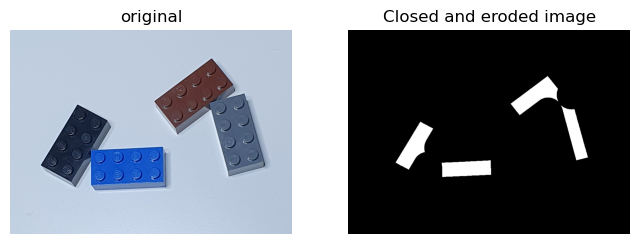

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


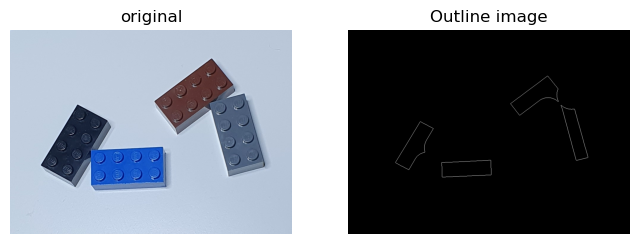

In [131]:
# Repaired image from ex 12
closed = closing(bin_img, disk(5))

eroded = erosion(closed, disk(44))
plot_comparison(im_org, eroded, 'Closed and eroded image')
outline_img = compute_outline(eroded)
plot_comparison(im_org, outline_img, 'Outline image')

## Exercise 14

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


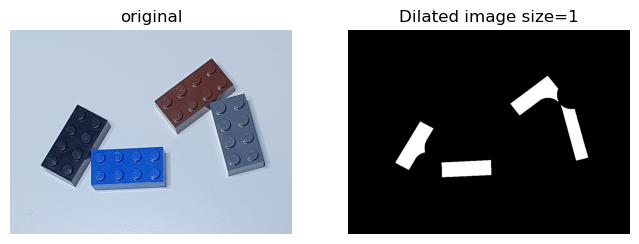

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


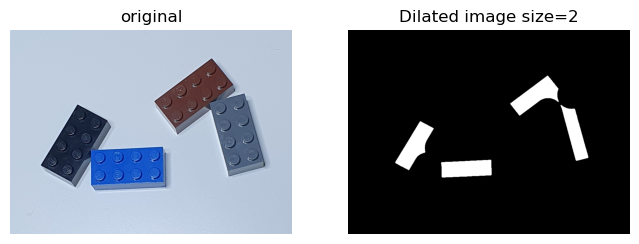

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


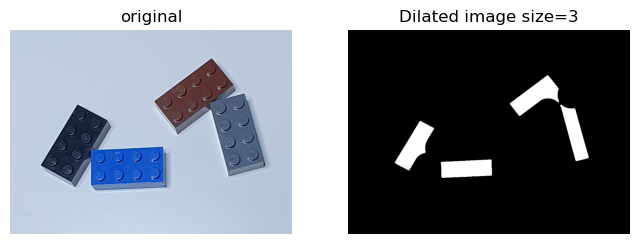

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


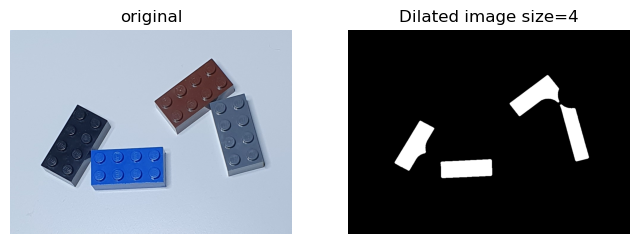

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


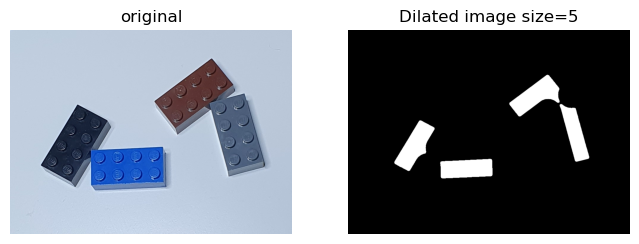

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


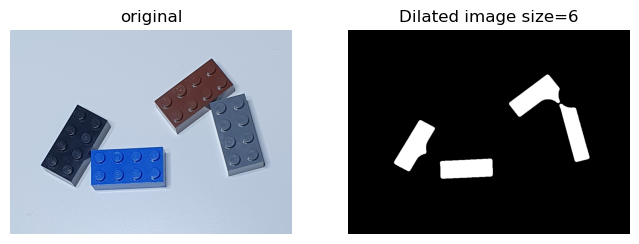

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


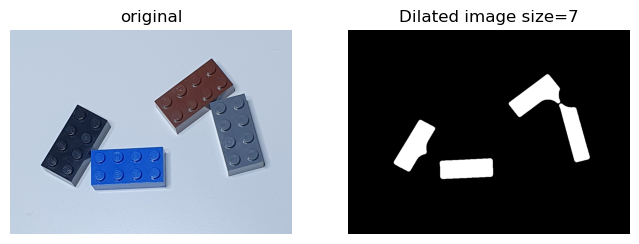

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


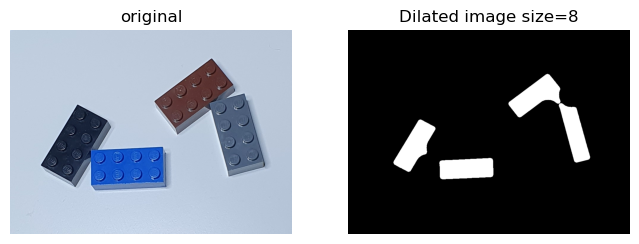

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


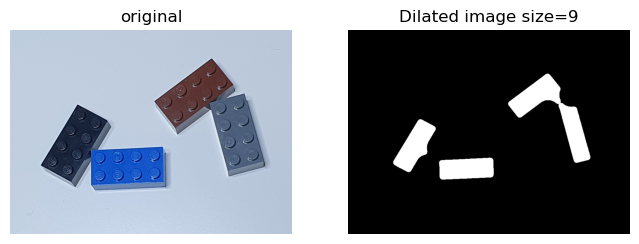

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_87313/4238744873.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


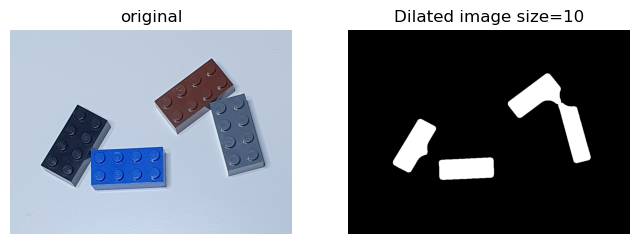

In [133]:
for i in range(1,11):
    dilated = dilation(eroded, disk(i))
    plot_comparison(im_org, dilated, f'Dilated image size={i}')